# AutoPrompt vs Baseline Experiment (StarCoderBase‑1B)

This notebook:
1. Loads code-generation datasets stored locally
2. Runs a baseline prompt on **bigcode/starcoderbase‑1b**
3. Applies a simple AutoPrompt optimisation loop (gradient‑based hard prompts)
4. Compares metrics (CodeBLEU, Exact‑Match, Latency)
5. Saves artefacts (CSV, PNG, final prompt text)

> **Note**  
> *Requires* CUDA GPU with ≥ 4 GB VRAM (16 GB recommended) and Python 3.10.  
> Update `baseline_prompt.yaml` if dataset paths/templates differ.


In [1]:
# ╒═════════════════════════════════════════╕
# | Install requirements (first run only)  |
# ╘═════════════════════════════════════════╛
# If everything is already installed, you can skip this cell
# %%bash
# pip install -r requirements.txt

In [2]:
# ╒═════════════════════════════════════════╕
# | Imports & device                       |
# ╘═════════════════════════════════════════╛
import os, sys, json, random, time, math
from pathlib import Path
import yaml
import torch
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# CodeBLEU: add custom path (edit if needed)
sys.path.append(r"C:\work projects\ITMO\NIR\external")
sys.path.append(r"C:\work projects\ITMO\NIR\external\codebleu")
from codebleu.my_calc_code_blue import calc_codebleu

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
torch.manual_seed(42)

Device: cuda


In [3]:
from huggingface_hub import login

login(token="TOKEN")

In [4]:
# ╒═════════════════════════════════════════╕
# | Load YAML config                       |
# ╘═════════════════════════════════════════╛
CFG_PATH = "baseline_prompt.yaml"  # ensure the file exists next to this notebook
CFG = yaml.safe_load(open(CFG_PATH, "r", encoding="utf8"))

SAVE_ROOT = Path("results") / ("run_" + time.strftime("%Y%m%d_%H%M%S"))
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
print("Results will be saved to", SAVE_ROOT)

SAMPLE_SIZE = 100  # smoke‑test size; change to None for full dataset



Results will be saved to results\run_20250629_122522


In [5]:
# ╒═════════════════════════════════════════╕
# | Helper: load local JSONL               |
# ╘═════════════════════════════════════════╛
def load_local_jsonl(path, sample_size=None):
    rows = []
    with open(path, encoding="utf8") as f:
        for ln in f:
            rows.append(json.loads(ln))

    # если выборка меньше, берём всё, иначе случайную подвыборку
    if sample_size and len(rows) > sample_size:
        rows = random.sample(rows, sample_size)

    return Dataset.from_list(rows)


datasets = {}
for name, spec in CFG["datasets"].items():
    full_path = Path(CFG["root"]) / spec["file"]
    ds = load_local_jsonl(full_path, SAMPLE_SIZE)
    datasets[name] = {
        "data": ds,
        "template": spec["template"],
        "max_new_tokens": spec["max_new_tokens"],
    }
    print(name, len(ds), "examples")

humaneval 100 examples
mbpp 100 examples
conala 95 examples
conala_mined 100 examples


In [6]:
# ╒═════════════════════════════════════════╕
# | Load StarCoderBase‑1B model            |
# ╘═════════════════════════════════════════╛
MODEL_NAME = CFG["model_name"]
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
).eval()
print("Model loaded.")

Model loaded.


In [7]:
# ╒═════════════════════════════════════════╕
# | Baseline evaluation function           |
# ╘═════════════════════════════════════════╛
@torch.no_grad()
def eval_baseline(dataset, template, max_tokens):
    preds, refs, lats = [], [], []
    for row in tqdm(dataset, desc="baseline"):
        prompt = template.replace("{input}", row["input"])
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        start = time.time()
        out = model.generate(**inputs, max_new_tokens=max_tokens)
        elapsed = (time.time() - start) * 1000
        lats.append(elapsed)
        gen_text = tokenizer.decode(out[0], skip_special_tokens=True)[
            len(prompt) :
        ].strip()
        preds.append(gen_text)
        refs.append(row["target"].strip())
    em = sum(p == r for p, r in zip(preds, refs)) / len(refs)
    cb = calc_codebleu(refs, preds, lang="python", weights=(0.5, 0.5, 0.0, 0.0))[
        "codebleu"
    ]
    return {"EM": em, "CodeBLEU": cb, "Latency": sum(lats) / len(lats), "preds": preds}

In [8]:
class AutoPrompt:
    def __init__(self, model, tokenizer, n_tokens: int = 3, lr: float = 1e-1):
        self.model, self.tok = model, tokenizer
        self.n_tokens = n_tokens
        self.vocab_size = tokenizer.vocab_size
        # инициализируем learnable-логиты маленьким шумом (FP32)
        self.emb_logits = torch.nn.Parameter(
            torch.randn(n_tokens, self.vocab_size, device=device) * 0.01
        )
        self.optimizer = torch.optim.Adam([self.emb_logits], lr=lr)

    def _soft_prompt_embeds(self) -> torch.Tensor:
        """
        Преобразуем logits → softmax → взвешенные эмбеддинги (n_tokens, hidden)
        dtype приводим к dtype эмбеддингов модели (обычно float16).
        """
        # (n_tokens, vocab)
        probs = torch.softmax(self.emb_logits, dim=-1)
        # весовой словарь модели (vocab, hidden)
        emb_matrix = self.model.get_input_embeddings().weight
        # !!! Приводим probs к тому же dtype, что и emb_matrix (Half)
        probs = probs.to(emb_matrix.dtype)
        # (n_tokens, hidden)
        return probs @ emb_matrix

    def optimise(self, dataset, n_iters: int = 8):
        for it in range(n_iters):
            total_loss = 0.0
            for row in dataset:
                # 1) токенизируем
                inp_ids = self.tok(row["input"], return_tensors="pt").input_ids[0].to(device)
                tgt_ids = self.tok(row["target"], return_tensors="pt").input_ids[0].to(device)
    
                # 2) формируем последовательность [prompt] + input + target
                seq_ids = torch.cat([inp_ids, tgt_ids], dim=0)           # (L_inp + L_tgt)
                seq_emb = self.model.get_input_embeddings()(seq_ids)     # (L, hidden)
                soft_emb = self._soft_prompt_embeds()                    # (n_tokens, hidden)
                full_emb = torch.cat([soft_emb, seq_emb], dim=0).unsqueeze(0)
    
                # 3) labels: игнорируем loss на prompt+input, считаем только на target
                ignore = torch.full((self.n_tokens + len(inp_ids),), -100, device=device)
                labels = torch.cat([ignore, tgt_ids], dim=0).unsqueeze(0)
    
                # 4) шаг оптимизации
                out = self.model(inputs_embeds=full_emb, labels=labels)
                loss = out.loss
                total_loss += loss.item()
    
                self.optimizer.zero_grad(set_to_none=True)
                loss.backward()
                self.optimizer.step()
    
            print(f"Iter {it+1}/{n_iters} – avg loss: {total_loss/len(dataset):.4f}")
    
        hard_ids = self.emb_logits.argmax(dim=-1).tolist()
        return " ".join(self.tok.convert_ids_to_tokens(hard_ids))


In [9]:
# ╒═════════════════════════════════════════╕
# | Run baseline & AutoPrompt              |
# ╘═════════════════════════════════════════╛
results = {}
for name, obj in datasets.items():
    ds = obj["data"]
    tmpl = obj["template"]
    max_tok = obj["max_new_tokens"]
    print("\n===", name.upper(), "===")
    res_base = eval_baseline(ds, tmpl, max_tok)
    results[f"{name}_baseline"] = res_base

    ap = AutoPrompt(model, tokenizer, n_tokens=3)
    learned_prefix = ap.optimise(ds, n_iters=8)
    full_tmpl = learned_prefix + " " + tmpl
    Path(SAVE_ROOT / f"final_prompt_{name}.txt").write_text(full_tmpl, encoding="utf8")
    res_ap = eval_baseline(ds, full_tmpl, max_tok)
    results[f"{name}_autoprompt"] = res_ap


=== HUMANEVAL ===


baseline:   0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for o

Iter 1/8 – avg loss: 0.8492
Iter 2/8 – avg loss: 0.8170
Iter 3/8 – avg loss: 0.7835
Iter 4/8 – avg loss: 0.7660
Iter 5/8 – avg loss: 0.7564
Iter 6/8 – avg loss: 0.7567
Iter 7/8 – avg loss: 0.7432
Iter 8/8 – avg loss: 0.7293


baseline:   0%|          | 0/100 [00:00<?, ?it/s]

...

baseline:   0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for o

Iter 1/8 – avg loss: 2.4706
Iter 2/8 – avg loss: 2.2956
Iter 3/8 – avg loss: 2.2339
Iter 4/8 – avg loss: 2.1946
Iter 5/8 – avg loss: 2.1788
Iter 6/8 – avg loss: 2.1673
Iter 7/8 – avg loss: 2.1599
Iter 8/8 – avg loss: 2.1552


baseline:   0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for o

In [10]:
# ╒═════════════════════════════════════════╕
# | Aggregate & save metrics               |
# ╘═════════════════════════════════════════╛
df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Run"})
csv_path = SAVE_ROOT / "metrics.csv"
df.to_csv(csv_path, index=False)
df

,Run,EM,CodeBLEU,Latency,preds
0,humaneval_baseline,0.0,0.011532,717.779443,"[, # +\n# Test your code\n\nassert separate_pa..."
1,humaneval_autoprompt,0.0,0.010594,457.651098,"[, # +\n# Test your code\n\nassert separate_pa..."
2,mbpp_baseline,0.0,0.029319,1601.253865,"[```python\ndef remove_k_length_words(string, ..."
3,mbpp_autoprompt,0.0,0.028695,2778.244872,"[```python\ndef remove_words(s, k):\n retur..."
4,conala_baseline,0.0,0.035142,1396.347884,[```python\ndef concat(x):\n return sum(x)\...
5,conala_autoprompt,0.0,0.029581,926.407914,[```python\ndef concat(x):\n return sum(x)\...
6,conala_mined_baseline,0.0,0.009926,767.554915,[```python\nfrom tkinter import *\n\nroot = Tk...
7,conala_mined_autoprompt,0.0,0.007389,765.288837,[```python\nfrom tkinter import *\n\nroot = Tk...


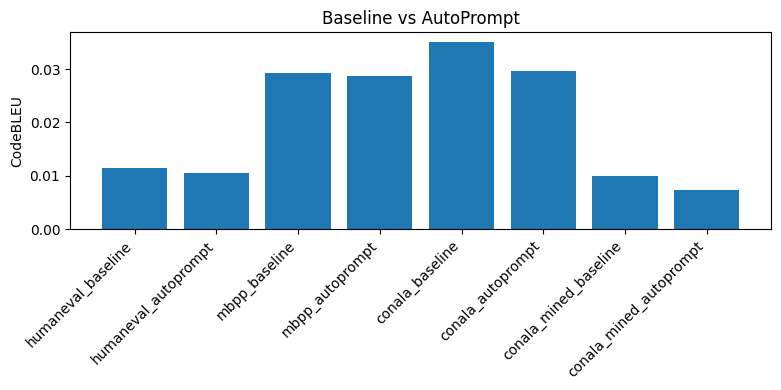

Saved: results\run_20250629_122522\codebleu_bar.png


In [11]:
# ╒═════════════════════════════════════════╕
# | Bar chart CodeBLEU                     |
# ╘═════════════════════════════════════════╛
plt.figure(figsize=(8, 4))
plt.bar(df["Run"], df["CodeBLEU"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("CodeBLEU")
plt.title("Baseline vs AutoPrompt")
plt.tight_layout()
png_path = SAVE_ROOT / "codebleu_bar.png"
plt.savefig(png_path, dpi=150)
plt.show()
print("Saved:", png_path)

In [12]:
# ╒═════════════════════════════════════════╕
# | Summary print                          |
# ╘═════════════════════════════════════════╛
for k, v in results.items():
    print(
        f'{k:20s}: CB={v["CodeBLEU"]:.2f}  EM={v["EM"]*100:.1f}%  Lat={v["Latency"]:.0f} ms'
    )
print("\nArtifacts in", SAVE_ROOT)

humaneval_baseline  : CB=0.01  EM=0.0%  Lat=718 ms
humaneval_autoprompt: CB=0.01  EM=0.0%  Lat=458 ms
mbpp_baseline       : CB=0.03  EM=0.0%  Lat=1601 ms
mbpp_autoprompt     : CB=0.03  EM=0.0%  Lat=2778 ms
conala_baseline     : CB=0.04  EM=0.0%  Lat=1396 ms
conala_autoprompt   : CB=0.03  EM=0.0%  Lat=926 ms
conala_mined_baseline: CB=0.01  EM=0.0%  Lat=768 ms
conala_mined_autoprompt: CB=0.01  EM=0.0%  Lat=765 ms

Artifacts in results\run_20250629_122522
